<a href="https://colab.research.google.com/github/nanduvarghese-glitch/gen-ai/blob/main/image_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from PIL import Image

In [10]:
from PIL import Image
image = Image.open('/content/ben_10.jpeg')

In [13]:
image_resized=image.resize((400,225))

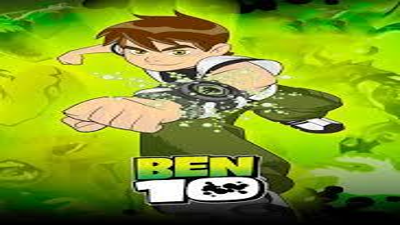

In [14]:
image_resized

In [15]:
import numpy as np

In [16]:
image_array=np.array(image)/255.0
# /255 is used for standardization of a image

In [17]:
image_array

array([[[0.14509804, 0.24705882, 0.0627451 ],
        [0.14509804, 0.24705882, 0.0627451 ],
        [0.14509804, 0.24705882, 0.0627451 ],
        ...,
        [0.23921569, 0.45490196, 0.04705882],
        [0.27058824, 0.48627451, 0.07843137],
        [0.29019608, 0.50980392, 0.09019608]],

       [[0.14901961, 0.25098039, 0.06666667],
        [0.14901961, 0.25098039, 0.0627451 ],
        [0.14901961, 0.25098039, 0.06666667],
        ...,
        [0.25098039, 0.46666667, 0.05882353],
        [0.29411765, 0.50980392, 0.10196078],
        [0.23137255, 0.44705882, 0.03921569]],

       [[0.15294118, 0.25490196, 0.06666667],
        [0.15294118, 0.25882353, 0.05882353],
        [0.15294118, 0.25490196, 0.06666667],
        ...,
        [0.28627451, 0.49411765, 0.08627451],
        [0.34117647, 0.54509804, 0.14901961],
        [0.15294118, 0.35686275, 0.        ]],

       ...,

       [[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0

array([[ 46,  46,  46, ...,  79,  87,  92],
       [ 47,  47,  47, ...,  82,  93,  77],
       [ 48,  48,  48, ...,  89, 103,  58],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
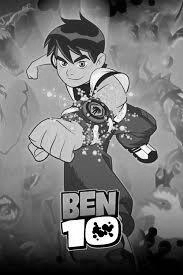

In [20]:
from cv2 import cvtColor,COLOR_BGR2GRAY
image_np=np.array(image)
grayscale_image=cvtColor(image_np,COLOR_BGR2GRAY)
grayscale_image

In [21]:
from PIL import Image,ImageEnhance,ImageOps

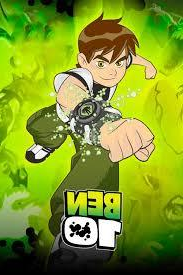

In [23]:
flipped=ImageOps.mirror(image)
flipped

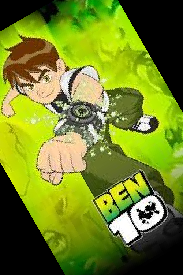

In [25]:
rotated=image.rotate(30)
rotated

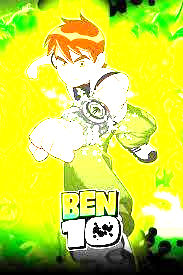

In [30]:
# brightness
enhancer=ImageEnhance.Brightness(image)
brighter=enhancer.enhance(2.5)
brighter


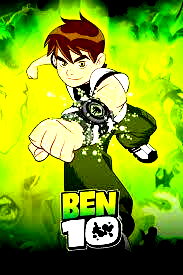

In [32]:
contrast = ImageEnhance.Contrast(image).enhance(2.0)
contrast

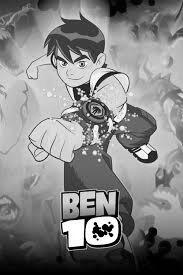

In [33]:
grayscale = ImageOps.grayscale(image)
grayscale

In [34]:
import os

In [36]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/ben_10.jpeg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


In [45]:
from PIL import Image

In [46]:
import matplotlib.pyplot as plt
import os


In [48]:
plt.figure(figsize=(12,8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [52]:
augmented_images=os.listdir(augmented_dir)

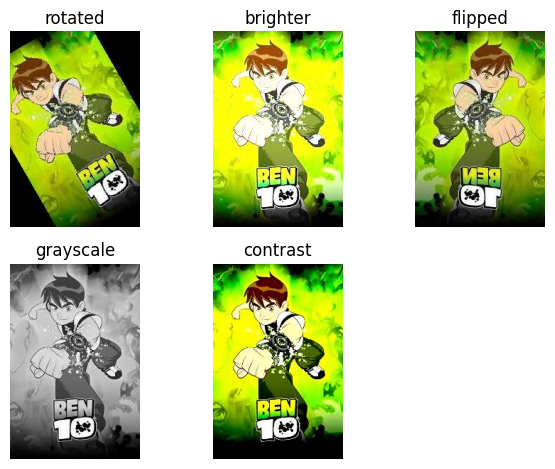

In [53]:
for i, img_file in enumerate(augmented_images):
  img_path=os.path.join(augmented_dir,img_file)
  img=Image.open(img_path)
  plt.subplot(2,3,i+1)
  plt.imshow(img,cmap='gray' if img.mode=='L' else None)
  plt.title(img_file.split('.')[0])
  plt.axis('off')
plt.tight_layout()
plt.show()
